<a href="https://colab.research.google.com/github/bobo33772-blip/AI_study/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝, 머신러닝

## 목표:예측
- 회귀(숫자)
- 분류(이진,다중)

- 전처리
  - 타겟 -> 0,1,2,3 형태로 변환(문자를 숫자로 변환할 때 LabelEncoder사용)
  - 특성(입력값) -> 숫자로 변환(원핫 인코딩)
- 다중분류(타겟이 여러개) -> iris품종예측
  - 출력층 - Dense(분류갯수, activation="softmax")
  - 컴파일 - compile(loss="sparse_categorical_crossentropy", metrics=["acc"])
  - 예측 - pred = model.predict(x_test) -> [[0.612, 0.012, ...]] 클래스별 확률값 반환  
           cls = np.argmax(pred) -> [[1],[0],]확률이 가장 큰 순번 추출

  - 출력층 - Dense(1, activation="softmax")  --> 예측값이 라벨(순번)
  - 컴파일 - compile(loss="categorical_crossentropy", metrics=["acc"])
  - 예측 - pred = model.predict(x_test) -> [[1],[0],]확률이 가장 큰 순번 추출

- 이진분류(타겟이 0,1) 타이타닉 생존예측
  - 출력층 - Dense(1, activation="sigmoid")  --> 예측값이 1일 확률
  - 컴파일 - compile(loss="binary_crossentropy", metrics=["acc"])
  - 예측 - pred = model.predict(x_test) -> [[0.65,],[0.12]] 1일 확률 추출  
           "1" if pred > 0.5 "0"

- 회귀(타겟이 숫자) 집값예측
  - 출력층 - Dense(1) activation="linear" 생략(기본값)
  - 컴파일 - compile(loss="mse", metrics=["mae"])  
    mse: mean squared error(오차제곱합)  
    mae: mean absolute error(오차절대값합)
  - 예측 - pred = model.predict(x_test) -> [[50],[43]]



## 코딩순서
1. 데이터로딩(csv)
2.입력(X),타겟(y) 분리
3. 입력의 문자형을 원핫인코딩, y의 문자형을 라벨로 변환
4. 입력값의 표준화 - StandardScaler() 적용
5. train, test 분리 - train_test_split()
6. 모델 생성(Sequential(), Input(), Dense(), compile()
7. 학습 - fit()
8. 예측, 평가점수 계산 - predict(), evaluate()

In [ ]:
# iris 품종 예측

# 1. 데이터로딩
import pandas as pd
url='https://raw.githubusercontent.com/mwaskom/seaborn-data/refs/heads/master/iris.csv'
iris = pd.read_csv(url)
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: >

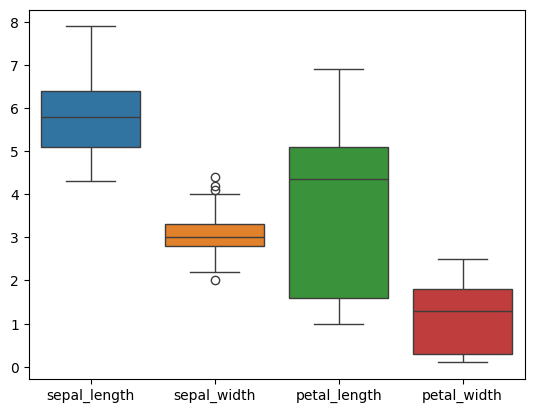

In [ ]:
import seaborn as sns
sns.boxplot(iris) # 이상치 확인

In [ ]:
iris['species'].value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [ ]:
y= iris['species']
X = iris.drop(columns='species')
# X = iris.drop(columns='species')

In [ ]:
# y_enc = y.map({'setosa':0,
#        'versicolor':1,
#        'virginica':2})
# print('y_enc',y_enc)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('y_enc',y_enc)
print(le.classes_)

y_enc [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']


In [ ]:
# train, test 분리
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y_enc,
    random_state=42,
    test_size=0.2,
    stratify=y_enc
)
print('X_train',x_train.shape)
print('X_test',x_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

import pandas as pd
print(pd.Series(y_train).value_counts())
print(pd.Series(y_test).value_counts())
# 각 클래스별 비율 출력
print(pd.Series(y_train).value_counts(normalize=True))
print(pd.Series(y_test).value_counts(normalize=True))

X_train (120, 4)
X_test (30, 4)
y_train (120,)
y_test (30,)
0    40
2    40
1    40
Name: count, dtype: int64
0    10
2    10
1    10
Name: count, dtype: int64
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


In [ ]:
# 모델 생성 Sequential
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(3, activation='softmax'))
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,091 (35.51 KB)

 Trainable params: 9,091 (35.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss="sparse_categorical_crossentropy",
    metrics=['acc']
    )

In [ ]:
model.fit(
    x_train,
    y_train,
    epochs=50,
    # batch_size=10,
    # validation_split=0.2
    verbose=1 # 학습 메세지 안나옴
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9583 - loss: 0.1043
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - acc: 0.9667 - loss: 0.0745
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - acc: 0.9500 - loss: 0.0981
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.9583 - loss: 0.0860
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - acc: 0.9750 - loss: 0.0754
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - acc: 0.9583 - loss: 0.0783 
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - acc: 0.9667 - loss: 0.0830
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - acc: 0.9750 - loss: 0.0758
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.9500 - loss: 0.1265
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.9417 - loss: 0.0910 
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - acc: 0.9667 - loss: 0.0745
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - acc: 0.9833 - loss: 0.0736
Epoch 13/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.

In [ ]:
pred = model.predict(x_test[:5])
print(pred) # 클래스별 확률

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
[[9.99797165e-01 2.02829484e-04 1.13780256e-10]
 [4.98580675e-07 4.19373721e-01 5.80625832e-01]
 [1.51643727e-03 9.97647703e-01 8.35864339e-04]
 [1.17212976e-03 9.97992158e-01 8.35767540e-04]
 [9.99860525e-01 1.39461627e-04 5.67572482e-11]]


In [ ]:
import numpy as np
print(np.argmax(pred, axis=1))
print(y_test[:5])

[0 2 1 1 0]
[0 2 1 1 0]


In [ ]:
# 다중분류(레이블 출력)
# 모델 생성 Sequential
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
# Dense(3,) -> 클래스(종류)별 확률 출력
# Dense(1,) -> 클래스(종류) 출력
model.add(Dense(1, activation='softmax'))
# model.summary()

model.compile(
    # Dense(3,) -> loss="sparse_categorical_crossentropy",
    # Dense(1,) -> loss="categorical_crossentropy",
    loss="categorical_crossentropy",
    metrics=['acc'])

model.fit(
    x_train,
    y_train,
    epochs=50,
    # batch_size=10,
    # validation_split=0.2,
    verbose=0 # 학습 메시지 안나옴
)

pred = model.predict( x_test[:5] )
print(pred) # 클래스
print(y_test[:5])

/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/losses/losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[1.]
 [1.]
 [1.]
 [1.]
 [1.]]
[0 2 1 1 0]


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (5, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [ ]:
# 타이타닉 생존예측(이진분류)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv'
titanic = pd.read_csv(url)
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [51]:
# 결측치 처리
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
titanic['Embarked'] = titanic['Embarked'].fillna('S')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
# x,y 분리
y = titanic['Survived']
x = titanic['Pclass,Sex,Age,SibSp,Parch,Fare,Embarked'.split(',')]
# 문자열을 원핫인코딩 [1,0,0,0]
import pandas as pd
x_enc = pd.get_dummies(x, columns=['Pclass','Sex','Embarked'],dtype=int)


In [53]:
# train, test 분리
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_enc,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)
print('X_train',x_train.shape)
print('X_test',x_test.shape)
print('y_train',y_train.shape)
print('y_test',y_test.shape)

X_train (712, 12)
X_test (179, 12)
y_train (712,)
y_test (179,)


In [54]:
# 모델 생성 Sequential
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape=(x_enc.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
# model.summary()

In [60]:
model.compile(
    loss="binary_crossentropy", #
    metrics=['acc']) #

In [58]:
model.fit(
    x_train,
    y_train,
    epochs=50,
    # batch_size=10,
    # validation_split=0.2,
    verbose=1 # 학습 메시지 안나옴
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8160 - loss: 0.4873   
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7949 - loss: 0.4519 
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8202 - loss: 0.4196 
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8188 - loss: 0.4264 
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8090 - loss: 0.4389 
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8146 - loss: 0.4122 
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8315 - loss: 0.4011
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8343 - loss: 0.4049 
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8118 - loss: 0.4522 
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8146 - loss: 0.4596 
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8244 - loss: 0.4309 
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8132 - loss: 0.4143 
Epoch 13/50
23/23 ━━━━━━━━━━━━━━━━━━

In [64]:
# 예측
pred = model.predict(x_test[:5])
print(pred)
print([1 if p > 0.5 else 0 for p in pred])
print(y_test[:5])
# 평가점수
score = model.evaluate(x_test, y_test)
print('score',score)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
[[0.11898395]
 [0.02764841]
 [0.10830716]
 [0.02502652]
 [0.52018833]]
[0, 0, 0, 0, 1]
565    0
160    0
553    1
860    0
241    1
Name: Survived, dtype: int64
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.7821 - loss: 0.5487 
score [0.5487381219863892, 0.7821229100227356]


In [65]:
# 회귀(보스턴 집값 예측)

url='https://raw.githubusercontent.com/selva86/datasets/refs/heads/master/BostonHousing.csv'
boston = pd.read_csv(url)
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [66]:
boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [68]:
boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


<Axes: >

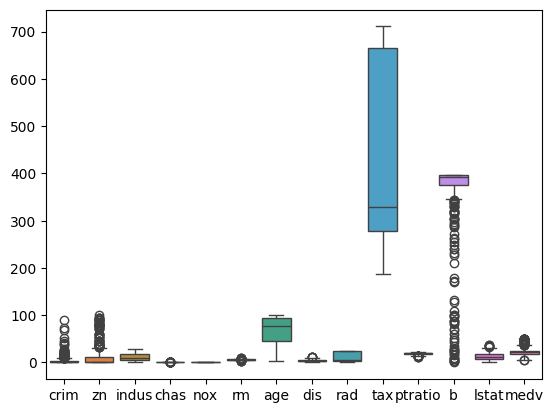

In [69]:
import seaborn as sns
sns.boxplot(boston)

In [67]:
# 결측치 없음
# 입력(X), 타겟(y) 분리
y = boston['medv']
x = boston.drop(columns='medv')

In [70]:
# 표준화작업 standardscaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [71]:
# train, test 분리 - train_test_split()
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_scaled,
    y,
    random_state=42,
    test_size=0.2
)

In [72]:
# 모델 생성 - Sequential(), Input(), Dense() , compile()
from keras.models import Sequential
from keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1)) # 회귀인 경우 활성화함수 생략. 기본값은 linear
# model.summary()

In [73]:
# 컴파일
model.compile(
    loss="mse", # mean squared error
    metrics=['mae'] # mean absolute error
)

# 학습 - fit()
model.fit(
    x_train,
    y_train,
    epochs=50,
    # batch_size=10,
    # validation_split=0.2
    verbose=1 # 학습 메세지 안나옴
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 555.4652 - mae: 21.6739
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 425.7036 - mae: 18.6112
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 287.0754 - mae: 14.8173
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 170.0337 - mae: 10.7771 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 95.8284 - mae: 7.7199 
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 58.4703 - mae: 5.8926
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 41.7562 - mae: 4.8885
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 32.5963 - mae: 4.2391
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.6805 - mae: 3.8524  
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.8118 - mae: 3.6518 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22.3091 - mae: 3.3941 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.3620 - mae: 3.2693 
Epoch 13/50
13/13

In [74]:
# 예측, 평가점수 계산 - predict(), evaluate()
pred = model.predict(x_test[:5])
print(pred)
score = model.evaluate(x_test, y_test)
print('score',score) # mse, mae값 출력

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[27.966518]
 [34.721996]
 [17.040163]
 [26.666811]
 [16.441097]]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 12.1261 - mae: 2.2739
score [12.126084327697754, 2.2738778591156006]


# 딥러닝 방법 3가지
- 회귀:숫자예측
- 이진분류: 답이0,1인 경우. 예측값은 1일 확률 반환
- 다중분류: 답이0,1,2,,예측값은 클래스별(종류) 확률 반환